<a href="https://colab.research.google.com/github/techasit239/DADS7202_PigPicture/blob/main/FreshCheck_AllInOne_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FreshCheck Deep Lab — All-in-One Colab
**Phase 0 → Phase 1 → Phase 2 รันต่อเนื่องในไฟล์เดียว**

**Course:** DADS 7202 Deep Learning · NIDA  
**Authors:** Jirapong (M) · Techasit (E) · Yingphan (D)

---

## เตรียมใน Google Drive ก่อนรัน

```
Google Drive/FreshCheck/
├── configs/
│   ├── kaggle.json               ← Kaggle → Settings → API → Create Legacy API Key
│   └── instances_default.json    ← ไฟล์ annotation (94 รูป)
└── data/
    ├── kaggle_meat/              ← dataset จาก Kaggle (notebook โหลดให้เอง)
    └── thai_fresh/               ← รูปที่ทีมถ่ายเอง 94 ใบ
```

**Runtime:** T4 GPU · Runtime → Change runtime type → T4 GPU → Run all

| Phase | งาน | เวลา |
|---|---|---|
| 0 | Download Kaggle + Group-aware split | ~3 นาที |
| 1 | เทรน EfficientNet-B0 | ~20 นาที |
| 2 | เทรน Swin-T + Thai test + TTA | ~30 นาที |
| | **รวม** | **~53 นาที** |

---
# PHASE 0 — Foundation Setup
---

In [1]:
# 0.1 — Imports + Seed + GPU
import os, re, random, json, time, shutil, io
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (f1_score, precision_score,
                             recall_score, confusion_matrix)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('[!] ไม่พบ GPU — Runtime → Change runtime type → T4 GPU')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
# 0.2 — Mount Drive + Define paths + Validate
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = '/content/drive/MyDrive/FreshCheck'
DATA_DRIVE   = f'{PROJECT_ROOT}/data/kaggle_meat'
THAI_IMG_DIR = f'{PROJECT_ROOT}/data/thai_fresh'
THAI_ANNO    = f'{PROJECT_ROOT}/configs/instances_default.json'
KAGGLE_JSON  = f'{PROJECT_ROOT}/configs/kaggle.json'
TRAIN_CSV    = f'{PROJECT_ROOT}/splits/kaggle_train.csv'
VAL_CSV      = f'{PROJECT_ROOT}/splits/kaggle_val.csv'
MODEL_DIR    = f'{PROJECT_ROOT}/models/classification'
LOGS_DIR     = f'{PROJECT_ROOT}/logs'
PHASE1_MODEL = f'{MODEL_DIR}/phase1_efficientnet_b0_best.pth'
PHASE2_MODEL = f'{MODEL_DIR}/phase2_swin_t_best.pth'
METRICS_JSON = f'{LOGS_DIR}/phase2_metrics.json'
DATA_LOCAL   = '/content/data_local/kaggle_meat'

for folder in ['data/kaggle_meat','data/thai_fresh','splits',
               'configs','models/classification','logs']:
    os.makedirs(f'{PROJECT_ROOT}/{folder}', exist_ok=True)

# Validate
print(f'Project root: {PROJECT_ROOT}\n')
all_ok = True
for label, path in [('kaggle.json', KAGGLE_JSON),
                     ('instances_default.json', THAI_ANNO),
                     ('thai_fresh/', THAI_IMG_DIR)]:
    ok = os.path.exists(path)
    if not ok: all_ok = False
    print(f'  {"[OK]  " if ok else "[FAIL]"}  {label}')

if not all_ok:
    print('\n[!] ไฟล์ขาดหาย — ดูหัวข้อ "เตรียมใน Google Drive" ด้านบน')
else:
    print('\n[OK] ทุกไฟล์พร้อม')

Mounted at /content/drive
Project root: /content/drive/MyDrive/FreshCheck

  [OK]    kaggle.json
  [OK]    instances_default.json
  [OK]    thai_fresh/

[OK] ทุกไฟล์พร้อม


In [3]:
# 0.3 — Download Kaggle Dataset (ข้ามถ้ามีอยู่แล้ว)
!pip install -q kaggle
import zipfile

def count_images(path):
    if not os.path.exists(path): return 0
    return sum(1 for f in Path(path).rglob('*')
               if f.suffix.lower() in ['.jpg','.jpeg','.png'])

if count_images(DATA_DRIVE) > 100:
    print(f'[OK] เจอข้อมูลเก่า {count_images(DATA_DRIVE)} รูป — ข้ามการดาวน์โหลด')
else:
    !mkdir -p ~/.kaggle
    !cp "{KAGGLE_JSON}" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    !cd /content && kaggle datasets download -d vinayakshanawad/meat-freshness-image-dataset
    with zipfile.ZipFile('/content/meat-freshness-image-dataset.zip','r') as z:
        z.extractall(DATA_DRIVE)
    print(f'[OK] ดาวน์โหลดเสร็จ — {count_images(DATA_DRIVE)} รูป')

[OK] เจอข้อมูลเก่า 2266 รูป — ข้ามการดาวน์โหลด


In [4]:
# 0.4 — Parse + Group-aware Split 80/20 (ข้ามถ้ามี CSV แล้ว)
if os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV):
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    print(f'[OK] โหลด splits จาก CSV — Train: {len(train_df)} | Val: {len(val_df)}')
else:
    def extract_class(filename):
        name = filename.upper()
        if name.startswith('HALF-FRESH') or name.startswith('HALFFRESH'): return 'HALF_FRESH'
        elif name.startswith('FRESH'):   return 'FRESH'
        elif name.startswith('SPOILED'): return 'SPOILED'
        return 'UNKNOWN'

    PIECE_PATTERN = re.compile(r'^([A-Z\-]+\d+)')
    def extract_piece_id(filename):
        m = PIECE_PATTERN.match(Path(filename).stem.upper())
        return m.group(1) if m else Path(filename).stem

    records = [{'filename': p.name, 'path': str(p),
                'class': extract_class(p.name),
                'piece_id': extract_piece_id(p.name)}
               for p in Path(DATA_DRIVE).rglob('*')
               if p.suffix.lower() in ['.jpg','.jpeg','.png']]

    df = pd.DataFrame(records)
    df = df[df['class'] != 'UNKNOWN'].reset_index(drop=True)
    print(f'Total: {len(df)} | {df["class"].value_counts().to_dict()}')

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
    train_idx, val_idx = next(gss.split(df, groups=df['piece_id']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    assert len(set(train_df['piece_id']) & set(val_df['piece_id'])) == 0, 'LEAK!'
    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV,   index=False)
    print(f'[OK] Train: {len(train_df)} | Val: {len(val_df)} | Saved splits')

[OK] โหลด splits จาก CSV — Train: 1812 | Val: 454


---
# PHASE 1 — EfficientNet-B0 (Baseline)
---

In [5]:
# 1.1 — Constants + Dataset Classes + Transforms
LABEL_MAP     = {'FRESH': 0, 'HALF_FRESH': 1, 'SPOILED': 2}
CLASSES       = ['FRESH', 'HALF_FRESH', 'SPOILED']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 2
DROPOUT       = 0.3
NUM_CLASSES   = 3
EPOCHS        = 15

# ── Dataset: Kaggle ──
class MeatDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, LABEL_MAP[row['class']]

# ── Dataset: Thai (crop จาก bbox) ──
class ThaiMeatDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
        img = img.crop((x, y, x+w, y+h))
        if self.transform: img = self.transform(img)
        return img, int(row['class_label'])

# ── Transforms ──
train_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_tf = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print('[OK] Constants, Dataset classes, Transforms ready')

[OK] Constants, Dataset classes, Transforms ready


In [6]:
# 1.2 — โหลด Thai Dataset (94 รูป, 1 bbox/รูป = bbox ใหญ่สุด)
with open(THAI_ANNO, 'r') as f:
    coco = json.load(f)

img_map = {img['id']: img for img in coco['images']}

# เอา bbox ที่ area ใหญ่สุดต่อรูป
img_best_ann = defaultdict(lambda: None)
for ann in coco['annotations']:
    iid = ann['image_id']
    if img_best_ann[iid] is None or ann['area'] > img_best_ann[iid]['area']:
        img_best_ann[iid] = ann

records = []
for img_id, ann in img_best_ann.items():
    info = img_map[img_id]
    x, y, w, h = ann['bbox']
    records.append({
        'filename'   : info['file_name'],
        'class'      : 'FRESH',
        'class_label': 0,
        'bbox_x': int(x), 'bbox_y': int(y),
        'bbox_w': int(w), 'bbox_h': int(h),
        'img_path'   : f'{THAI_IMG_DIR}/{info["file_name"]}',
    })

thai_df = pd.DataFrame(records)

# แบ่ง 70/30
thai_train_df = thai_df.sample(frac=0.7, random_state=SEED).reset_index(drop=True)
thai_test_df  = thai_df.drop(thai_train_df.index).reset_index(drop=True)

print(f'Thai images : {len(thai_df)} (1 bbox/รูป)')
print(f'Thai train  : {len(thai_train_df)} รูป → รวมเข้า Kaggle train')
print(f'Thai test   : {len(thai_test_df)} รูป  → ใช้ test เท่านั้น')

Thai images : 94 (1 bbox/รูป)
Thai train  : 66 รูป → รวมเข้า Kaggle train
Thai test   : 28 รูป  → ใช้ test เท่านั้น


In [7]:
# 1.3 — Copy data ไป local SSD + สร้าง DataLoaders
if os.path.exists(DATA_LOCAL) and len(os.listdir(DATA_LOCAL)) > 0:
    print('[OK] ข้อมูล local มีอยู่แล้ว')
else:
    print('กำลังคัดลอกข้อมูลไป /content ...')
    t0 = time.time()
    shutil.copytree(DATA_DRIVE, DATA_LOCAL)
    print(f'[OK] เสร็จใน {time.time()-t0:.1f} วินาที')

train_df['path'] = train_df['path'].str.replace(DATA_DRIVE, DATA_LOCAL, regex=False)
val_df['path']   = val_df['path'].str.replace(DATA_DRIVE, DATA_LOCAL, regex=False)

# รวม Thai train เข้า Kaggle train
combined_train_df = pd.concat([
    train_df[['path','class']],
    pd.DataFrame({'path': thai_train_df['img_path'], 'class': 'FRESH'})
], ignore_index=True)

train_loader = DataLoader(
    MeatDataset(combined_train_df, train_tf),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(
    MeatDataset(val_df, val_tf),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True)
thai_test_loader = DataLoader(
    ThaiMeatDataset(thai_test_df, val_tf),
    batch_size=8, shuffle=False, num_workers=2)

print(f'Combined train : {len(combined_train_df)} รูป '
      f'(Kaggle {len(train_df)} + Thai {len(thai_train_df)})')
print(f'Val loader     : {len(val_df)} รูป')
print(f'Thai test      : {len(thai_test_df)} รูป')

กำลังคัดลอกข้อมูลไป /content ...
[OK] เสร็จใน 49.0 วินาที
Combined train : 1878 รูป (Kaggle 1812 + Thai 66)
Val loader     : 454 รูป
Thai test      : 28 รูป


In [8]:
# 1.4 — Training Helpers (ใช้ร่วมกัน Phase 1+2)
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, total):
    model.train()
    loss_sum, correct, n = 0., 0, 0
    pbar = tqdm(loader, desc=f'Epoch {epoch:2d}/{total} [train]', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (model(imgs).argmax(1) == labels).sum().item()
        n        += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')
    return loss_sum/n, correct/n

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc='val'):
    model.eval()
    loss_sum, correct, n = 0., 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(imgs); preds = logits.argmax(1)
        loss_sum += criterion(logits, labels).item() * imgs.size(0)
        correct  += (preds == labels).sum().item(); n += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return loss_sum/n, correct/n, f1_score(all_labels, all_preds, average='macro'), all_preds, all_labels

def make_cos(model, df, epochs):
    cc = df['class'].value_counts()
    w  = torch.tensor([cc.sum()/(NUM_CLASSES*cc[c]) for c in CLASSES], dtype=torch.float).to(device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    return crit, opt, sch

def run_training(model, tr_loader, vl_loader, crit, opt, sch, save_path, epochs=15, patience=5):
    history, best_f1, no_improve = [], 0., 0
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, crit, opt, device, epoch, epochs)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, vl_loader, crit, device)
        lr = sch.get_last_lr()[0]; sch.step()
        is_best = val_f1 > best_f1
        if is_best:
            best_f1 = val_f1; no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improve += 1
        history.append({'epoch':epoch,'lr':lr,'train_loss':tr_loss,'train_acc':tr_acc,
                        'val_loss':val_loss,'val_acc':val_acc,'val_f1':val_f1})
        print(f'Epoch {epoch:2d}/{epochs} | lr={lr:.1e} | '
              f'train loss={tr_loss:.3f} acc={tr_acc:.3f} | '
              f'val loss={val_loss:.3f} acc={val_acc:.3f} f1={val_f1:.3f}'
              f'{" ★" if is_best else f" (no improve {no_improve}/{patience})"}')
        if no_improve >= patience:
            print(f'[Early stopping] epoch {epoch}'); break
    print(f'\n[OK] Best val Macro-F1: {best_f1:.4f} → {save_path}')
    return pd.DataFrame(history), best_f1

def plot_curves(hist_df, title, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (tr_col, val_col, t, yl) in zip(axes, [
        ('train_loss','val_loss','Loss','Loss'),
        ('train_acc','val_acc','Accuracy','Accuracy'),
        (None,'val_f1','Val Macro-F1','Macro-F1')]):
        if tr_col: ax.plot(hist_df['epoch'], hist_df[tr_col], 'o-', label='train', color='#1e3a5f')
        ax.plot(hist_df['epoch'], hist_df[val_col], 'o-', label='val', color='#c4583a')
        ax.set_title(f'{title} — {t}'); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=100); plt.show()

print('[OK] Helpers ready')

[OK] Helpers ready


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 108MB/s] 


EfficientNet-B0: 4.0M params

Starting EfficientNet-B0 training...


Epoch  1/15 [train]:   0%|          | 0/59 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

...

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 11/15 | lr=2.6e-05 | train loss=0.031 acc=0.991 | val loss=0.011 acc=0.996 f1=0.996 (no improve 4/5)


Epoch 12/15 [train]:   0%|          | 0/59 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 12/15 | lr=1.7e-05 | train loss=0.037 acc=0.987 | val loss=0.011 acc=0.998 f1=0.998 (no improve 5/5)
[Early stopping] epoch 12

[OK] Best val Macro-F1: 0.9981 → /content/drive/MyDrive/FreshCheck/models/classification/phase1_efficientnet_b0_best.pth


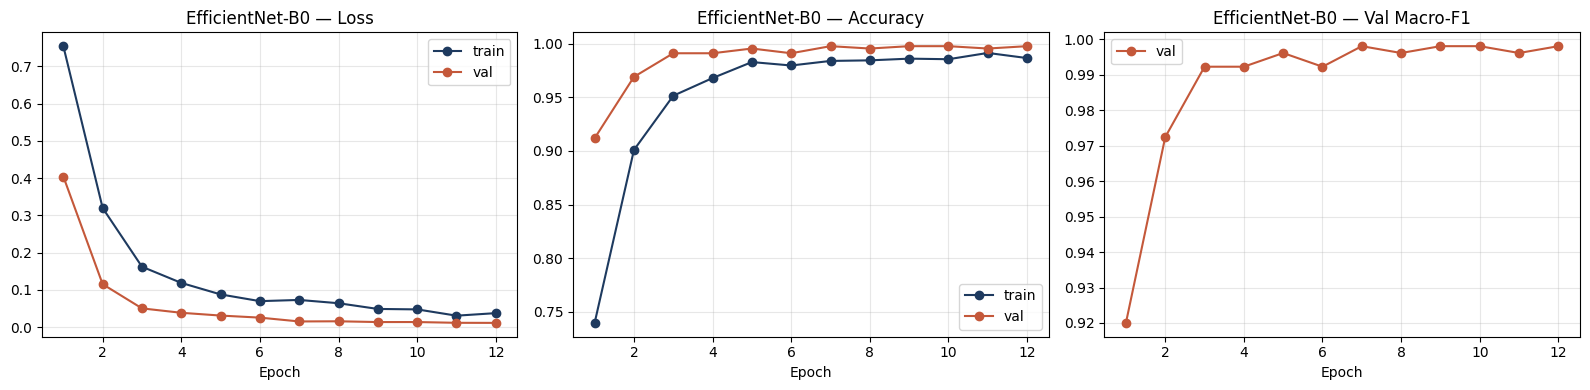

In [9]:
# 1.5 — Build + Train EfficientNet-B0
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT, inplace=True),
    nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES),
)
effnet = effnet.to(device)
print(f'EfficientNet-B0: {sum(p.numel() for p in effnet.parameters())/1e6:.1f}M params')

crit_eff, opt_eff, sch_eff = make_cos(effnet, combined_train_df, EPOCHS)
print('\nStarting EfficientNet-B0 training...')
hist_eff, best_f1_eff = run_training(
    effnet, train_loader, val_loader,
    crit_eff, opt_eff, sch_eff, PHASE1_MODEL, EPOCHS)
plot_curves(hist_eff, 'EfficientNet-B0', f'{LOGS_DIR}/phase1_curves.png')

---
# PHASE 2 — Swin-T + Thai Real-World Test
---

In [ ]:
# 2.1 — Build + Train Swin-T
swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
swin.head = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(swin.head.in_features, NUM_CLASSES),
)
swin = swin.to(device)
print(f'Swin-T: {sum(p.numel() for p in swin.parameters())/1e6:.1f}M params')

crit_sw, opt_sw, sch_sw = make_cos(swin, combined_train_df, EPOCHS)
print('\nStarting Swin-T training...')
hist_sw, best_f1_sw = run_training(
    swin, train_loader, val_loader,
    crit_sw, opt_sw, sch_sw, PHASE2_MODEL, EPOCHS)
plot_curves(hist_sw, 'Swin-T', f'{LOGS_DIR}/phase2_swin_curves.png')

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 176MB/s] 


Swin-T: 27.5M params

Starting Swin-T training...


Epoch  1/15 [train]:   0%|          | 0/59 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  1/15 | lr=1.0e-04 | train loss=0.433 acc=0.837 | val loss=0.122 acc=0.945 f1=0.952 ★


Epoch  2/15 [train]:   0%|          | 0/59 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  2/15 | lr=9.9e-05 | train loss=0.203 acc=0.929 | val loss=0.064 acc=0.978 f1=0.980 ★


Epoch  3/15 [train]:   0%|          | 0/59 [00:00<?, ?it/s]

In [ ]:
# 2.2 — โหลด best models + Evaluate บน Kaggle Val
effnet.load_state_dict(torch.load(PHASE1_MODEL, map_location=device))
swin.load_state_dict(torch.load(PHASE2_MODEL,   map_location=device))
crit_eval = nn.CrossEntropyLoss()

results_kaggle = {}
for name, model in [('EfficientNet-B0', effnet), ('Swin-T', swin)]:
    val_loss, val_acc, val_f1, preds, labels = evaluate(
        model, val_loader, crit_eval, device, desc=name)
    results_kaggle[name] = {
        'val_acc': val_acc, 'val_macro_f1': val_f1, 'val_loss': val_loss,
        'per_class_f1': dict(zip(CLASSES, f1_score(labels, preds, average=None).tolist())),
        'preds': preds, 'labels': labels,
    }

print('\n' + '='*60)
print(f'{"Model":<20} {"Accuracy":>10} {"Macro-F1":>10} {"Loss":>8}')
print('-'*60)
for name, r in results_kaggle.items():
    print(f'{name:<20} {r["val_acc"]:>10.4f} {r["val_macro_f1"]:>10.4f} {r["val_loss"]:>8.4f}')
print('='*60)

In [ ]:
# 2.3 — Confusion Matrix (Kaggle Val)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, r) in zip(axes, results_kaggle.items()):
    cm      = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=20); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Kaggle Val')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            color = 'white' if cm_norm[i,j] > 0.6 else 'black'
            ax.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                    ha='center', va='center', color=color, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f'{LOGS_DIR}/phase2_kaggle_cm.png', dpi=100); plt.show()

In [ ]:
# 2.4 — Thai Real-World Test
results_thai = {}
for name, model in [('EfficientNet-B0', effnet), ('Swin-T', swin)]:
    _, acc, f1, preds, labels = evaluate(
        model, thai_test_loader, crit_eval, device, desc=f'Thai [{name}]')
    results_thai[name] = {
        'acc': acc, 'macro_f1': f1,
        'fresh_f1': f1_score(labels, preds, average=None, labels=[0])[0],
        'preds': preds, 'labels': labels,
    }

n = len(thai_test_df)
print(f'\n{"="*55}')
print(f'Thai Real-World Test (n={n}, ทุกรูปเป็น FRESH)')
print(f'{"Model":<20} {"Accuracy":>10} {"Fresh-F1":>10}')
print(f'{"-"*55}')
for name, r in results_thai.items():
    correct = sum(1 for p in r['preds'] if p == 0)
    print(f'{name:<20} {r["acc"]:>10.4f} {r["fresh_f1"]:>10.4f}  ({correct}/{n} ถูก)')
print(f'{"="*55}')

In [ ]:
# 2.5 — Test-Time Augmentation (TTA)
tta_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

@torch.no_grad()
def evaluate_tta(model, dataset, device, n_aug=10):
    model.eval()
    all_preds, all_labels = [], []
    for idx in tqdm(range(len(dataset)), desc='TTA'):
        img_orig, label = dataset[idx]
        all_labels.append(label)
        probs = [torch.softmax(model(img_orig.unsqueeze(0).to(device)), dim=1).cpu()]
        row = dataset.df.iloc[idx]
        img_pil = Image.open(row['img_path']).convert('RGB')
        x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
        img_pil = img_pil.crop((x, y, x+w, y+h))
        for _ in range(n_aug):
            probs.append(torch.softmax(
                model(tta_tf(img_pil).unsqueeze(0).to(device)), dim=1).cpu())
        all_preds.append(torch.stack(probs).mean(0).argmax(1).item())
    acc      = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    fresh_f1 = f1_score(all_labels, all_preds, average=None, labels=[0])[0]
    return acc, fresh_f1, all_preds, all_labels

results_tta = {}
for name, model in [('EfficientNet-B0', effnet), ('Swin-T', swin)]:
    acc, fresh_f1, preds, labels = evaluate_tta(
        model, ThaiMeatDataset(thai_test_df, transform=val_tf), device, n_aug=10)
    results_tta[name] = {'acc': acc, 'fresh_f1': fresh_f1, 'preds': preds, 'labels': labels}

n = len(thai_test_df)
print(f'\n{"="*65}')
print(f'Thai Test — TTA (n_aug=10) vs Normal')
print(f'{"Model":<20} {"Normal Acc":>12} {"TTA Acc":>10} {"Normal F1":>12} {"TTA F1":>10}')
print(f'{"-"*65}')
for name in results_tta:
    rn = results_thai[name]; rt = results_tta[name]
    cn = sum(1 for p in rn['preds'] if p == 0)
    ct = sum(1 for p in rt['preds'] if p == 0)
    print(f'{name:<20} {rn["acc"]:>12.4f} {rt["acc"]:>10.4f} '
          f'{rn["fresh_f1"]:>12.4f} {rt["fresh_f1"]:>10.4f}')
    print(f'{"":20} ({cn}/{n} ถูก)    ({ct}/{n} ถูก)')
print(f'{"="*65}')

In [ ]:
# 2.6 — Final Summary + Precision/Recall/F1 + Save JSON
best_kaggle = max(results_kaggle, key=lambda n: results_kaggle[n]['val_macro_f1'])
best_thai   = max(results_tta,    key=lambda n: results_tta[n]['acc'])

def get_prf(labels, preds, avg='macro'):
    return (precision_score(labels, preds, average=avg, zero_division=0),
            recall_score(labels, preds, average=avg, zero_division=0),
            f1_score(labels, preds, average=avg, zero_division=0))

def get_prf_cls(labels, preds):
    return (precision_score(labels, preds, average=None, zero_division=0),
            recall_score(labels, preds, average=None, zero_division=0),
            f1_score(labels, preds, average=None, zero_division=0))

# ── Kaggle Val ──
print('='*70)
print('KAGGLE VALIDATION SET — Precision / Recall / F1')
print('='*70)
for name, r in results_kaggle.items():
    p_mac, r_mac, f1_mac = get_prf(r['labels'], r['preds'])
    p_cls, r_cls, f1_cls = get_prf_cls(r['labels'], r['preds'])
    print(f'\n── {name} ──')
    print(f'  {"":14} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-"*46}')
    for i, cls in enumerate(CLASSES):
        print(f'  {cls:<14} {p_cls[i]:>10.4f} {r_cls[i]:>10.4f} {f1_cls[i]:>10.4f}')
    print(f'  {"-"*46}')
    print(f'  {"Macro avg":<14} {p_mac:>10.4f} {r_mac:>10.4f} {f1_mac:>10.4f}')
    print(f'  Accuracy: {r["val_acc"]:.4f}')
    results_kaggle[name].update({'precision_macro': float(p_mac), 'recall_macro': float(r_mac),
        'per_class_precision': dict(zip(CLASSES, p_cls.tolist())),
        'per_class_recall':    dict(zip(CLASSES, r_cls.tolist()))})

# ── Thai Test (TTA) ──
n = len(thai_test_df)
print(f'\n{"="*70}')
print(f'THAI REAL-WORLD TEST (n={n}, all FRESH) — TTA Results')
print(f'{"="*70}')
for name, r in results_tta.items():
    p_cls, r_cls, f1_cls = get_prf_cls(r['labels'], r['preds'])
    p_mac, r_mac, f1_mac = get_prf(r['labels'], r['preds'])
    correct = sum(1 for p in r['preds'] if p == 0)
    print(f'\n── {name} ──')
    print(f'  {"":14} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-"*46}')
    for i, cls in enumerate(CLASSES):
        if f1_cls[i] > 0 or i == 0:
            print(f'  {cls:<14} {p_cls[i]:>10.4f} {r_cls[i]:>10.4f} {f1_cls[i]:>10.4f}')
    print(f'  {"-"*46}')
    print(f'  {"Macro avg":<14} {p_mac:>10.4f} {r_mac:>10.4f} {f1_mac:>10.4f}')
    print(f'  Accuracy: {r["acc"]:.4f}  ({correct}/{n} ถูก)')
    results_tta[name].update({'precision_macro': float(p_mac), 'recall_macro': float(r_mac),
        'precision_fresh': float(p_cls[0]), 'recall_fresh': float(r_cls[0])})

# ── Final Table ──
print(f'\n{"="*70}')
print('FINAL COMPARISON')
print(f'{"="*70}')
print(f'{"":20}  {"── Kaggle Val ──":^34}  {"── Thai (TTA) ──":^22}')
print(f'{"Model":<20}  {"Acc":>8} {"Prec":>8} {"Rec":>8} {"F1":>8}  {"Acc":>8} {"F1":>8}')
print('-'*70)
for name in results_kaggle:
    rk = results_kaggle[name]; rt = results_tta[name]
    print(f'{name:<20}  {rk["val_acc"]:>8.4f} {rk["precision_macro"]:>8.4f} '
          f'{rk["recall_macro"]:>8.4f} {rk["val_macro_f1"]:>8.4f}  '
          f'{rt["acc"]:>8.4f} {rt["fresh_f1"]:>8.4f}')
print('='*70)
print(f'\n★ Kaggle winner    : {best_kaggle}')
print(f'★ Thai TTA winner  : {best_thai}')

# ── Save JSON ──
metrics = {
    'phase': 'Phase 2 — Swin-T vs EfficientNet-B0',
    'results': {
        name: {
            'kaggle_val': {
                'accuracy': float(results_kaggle[name]['val_acc']),
                'precision_macro': float(results_kaggle[name]['precision_macro']),
                'recall_macro': float(results_kaggle[name]['recall_macro']),
                'macro_f1': float(results_kaggle[name]['val_macro_f1']),
                'per_class_precision': results_kaggle[name]['per_class_precision'],
                'per_class_recall': results_kaggle[name]['per_class_recall'],
                'per_class_f1': results_kaggle[name]['per_class_f1'],
            },
            'thai_test_tta': {
                'n': n, 'n_aug': 10,
                'accuracy': float(results_tta[name]['acc']),
                'precision_macro': float(results_tta[name]['precision_macro']),
                'recall_macro': float(results_tta[name]['recall_macro']),
                'fresh_f1': float(results_tta[name]['fresh_f1']),
                'precision_fresh': float(results_tta[name]['precision_fresh']),
                'recall_fresh': float(results_tta[name]['recall_fresh']),
            },
        } for name in results_kaggle
    },
    'winner': {'kaggle_val': best_kaggle, 'thai_tta': best_thai},
}
with open(METRICS_JSON, 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'\n[OK] Metrics saved: {METRICS_JSON}')
print('\nOutput files:')
for path in [PHASE1_MODEL, PHASE2_MODEL, METRICS_JSON,
             f'{LOGS_DIR}/phase1_curves.png',
             f'{LOGS_DIR}/phase2_swin_curves.png',
             f'{LOGS_DIR}/phase2_kaggle_cm.png']:
    size = os.path.getsize(path)/1024 if os.path.exists(path) else 0
    print(f'  {"[OK]" if os.path.exists(path) else "[--]"} {Path(path).name} ({size:.0f} KB)')